Logistic Regression
Accuracy: 0.7462959204384007
Precision: 0.7902566009669022
Recall: 0.7559587335467806
F1: 0.7727272727272727

Random Forest
Accuracy: 0.7682159529125229
Precision: 0.8235750290810392
Recall: 0.7556029882604055
F1: 0.788126159554731

Validation results
                 Model  Accuracy        F1
0  Logistic Regression  0.746296  0.772727
1        Random Forest  0.768216  0.788126


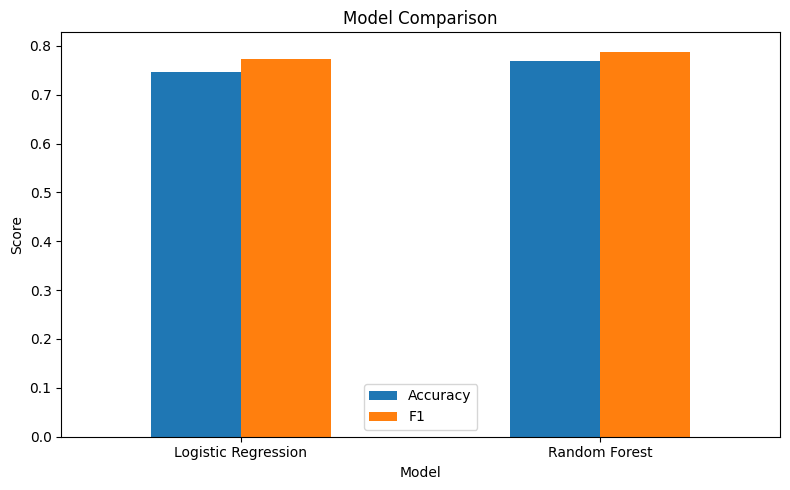


Test results (Random Forest)
Accuracy: 0.5319667140247615
Precision: 0.9590964590964591
Recall: 0.41233595800524936
F1: 0.5767254038179148


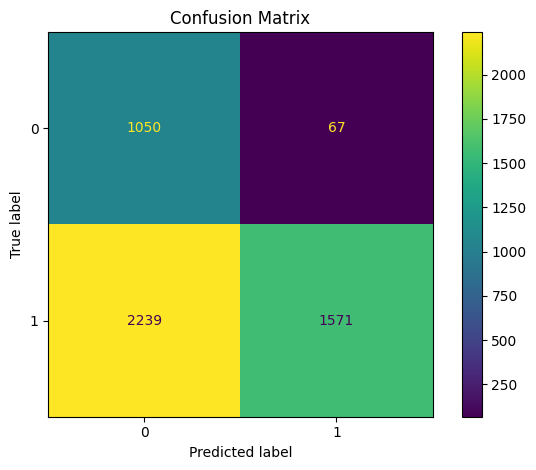

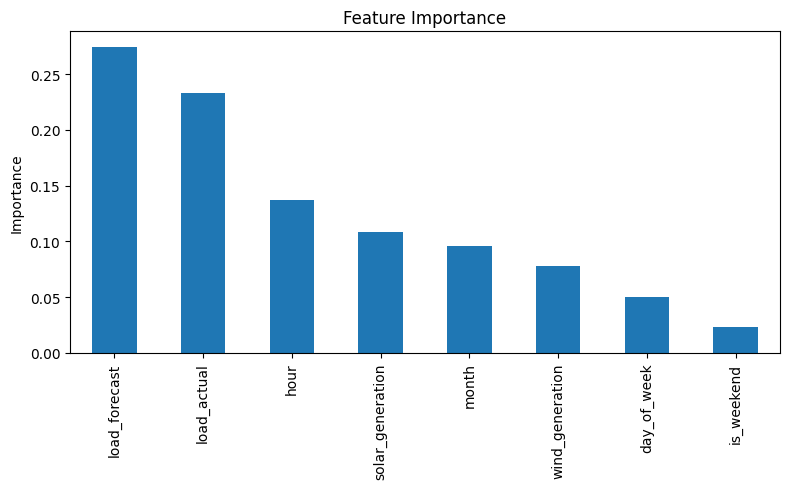

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import StandardScaler

# Load data
file_path = "../data/time_series_60min_singleindex.csv"
df = pd.read_csv(file_path)

# Keep only Austrian columns
columns_to_keep = [
    "cet_cest_timestamp",
    "AT_load_actual_entsoe_transparency",
    "AT_load_forecast_entsoe_transparency",
    "AT_price_day_ahead",
    "AT_solar_generation_actual",
    "AT_wind_onshore_generation_actual",
]

df_at = df[columns_to_keep].copy()
df_at.columns = [
    "timestamp",
    "load_actual",
    "load_forecast",
    "price_day_ahead",
    "solar_generation",
    "wind_generation",
]

# Basic cleaning
df_at["timestamp"] = pd.to_datetime(df_at["timestamp"], utc=True)
df_at = df_at.dropna(subset=["price_day_ahead"]).copy()
df_at["solar_generation"] = df_at["solar_generation"].fillna(0)
df_at["wind_generation"] = df_at["wind_generation"].fillna(0)

# Time-based features
df_at["hour"] = df_at["timestamp"].dt.hour
df_at["day_of_week"] = df_at["timestamp"].dt.dayofweek
df_at["month"] = df_at["timestamp"].dt.month
df_at["is_weekend"] = df_at["day_of_week"].isin([5, 6]).astype(int)

# Target variable
price_threshold = df_at["price_day_ahead"].median()
df_at["high_price"] = (df_at["price_day_ahead"] > price_threshold).astype(int)

# Feature set
feature_columns = [
    "load_actual",
    "load_forecast",
    "solar_generation",
    "wind_generation",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
]

# Sort by time before splitting
df_at = df_at.sort_values("timestamp").reset_index(drop=True)

X = df_at[feature_columns]
y = df_at["high_price"]

# Chronological split: 70% train, 15% validation, 15% test
n = len(df_at)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

# Logistic Regression uses scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
val_pred_log = log_reg.predict(X_val_scaled)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_val, val_pred_log))
print("Precision:", precision_score(y_val, val_pred_log))
print("Recall:", recall_score(y_val, val_pred_log))
print("F1:", f1_score(y_val, val_pred_log))

# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    random_state=42,
)
rf.fit(X_train, y_train)
val_pred_rf = rf.predict(X_val)

print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_val, val_pred_rf))
print("Precision:", precision_score(y_val, val_pred_rf))
print("Recall:", recall_score(y_val, val_pred_rf))
print("F1:", f1_score(y_val, val_pred_rf))

# Compare models on validation data
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_val, val_pred_log),
        accuracy_score(y_val, val_pred_rf),
    ],
    "F1": [
        f1_score(y_val, val_pred_log),
        f1_score(y_val, val_pred_rf),
    ],
})

print("\nValidation results")
print(results)

results.set_index("Model").plot(kind="bar", figsize=(8, 5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Final evaluation on test set
test_pred = rf.predict(X_test)

print("\nTest results (Random Forest)")
print("Accuracy:", accuracy_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred))
print("Recall:", recall_score(y_test, test_pred))
print("F1:", f1_score(y_test, test_pred))

cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Feature importance
importances = pd.Series(
    rf.feature_importances_,
    index=feature_columns
).sort_values(ascending=False)

importances.plot(kind="bar", figsize=(8, 5))
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()